# 05 — Factor Investing: Decomposing ETF Returns into Priced Risks

**Quantitative Markets Research Lab** · empirical asset pricing notebook

The central claim of factor models is deflationary: most of what looks like manager skill (or ETF "strategy") is compensation for exposure to a handful of systematic risks. Formally, we regress an asset's *excess* return on the Fama–French five factors plus momentum:

$$r_{i,t} - r_{f,t} = \alpha_i + \beta_{i,\text{Mkt}}\,\text{MktRF}_t + \beta_{i,\text{SMB}}\,\text{SMB}_t + \beta_{i,\text{HML}}\,\text{HML}_t + \beta_{i,\text{RMW}}\,\text{RMW}_t + \beta_{i,\text{CMA}}\,\text{CMA}_t + \beta_{i,\text{Mom}}\,\text{Mom}_t + \varepsilon_{i,t}.$$

The $\beta$s say *which* risks the asset carries; $\alpha$ is what remains — return unexplained by the factor menu. Under the model's null, $\alpha = 0$ for anything that isn't genuinely special (Fama & French, 2015; Carhart, 1997).

This notebook runs that regression on six ETFs whose marketing departments make explicit factor claims, using real daily data:

| ETF | Claim | If the claim is true, we should see |
|---|---|---|
| QQQ | Nasdaq-100 (mega-cap growth) | market $\beta > 1$, **negative** HML, negative SMB |
| USMV | minimum volatility | market $\beta$ well **below 1**, positive RMW/CMA tilt |
| MTUM | momentum | large positive **Mom** loading |
| VLUE | value | large positive **HML** loading |
| QUAL | quality (profitability) | positive **RMW** loading |
| IWM | small caps (Russell 2000) | large positive **SMB** loading |

The interesting scientific question is not whether the loadings appear (they will) but whether anything is left over — the alphas.

In [1]:
import sys, os, pathlib

ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9.5, 5), "figure.dpi": 100,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})

from src.data.market_data_loader import load_prices, to_returns
from src.data.factor_data_loader import load_ff_factors
from src.models.factor_models import fit_factor_model, rolling_betas

ETFS = ["QQQ", "USMV", "MTUM", "VLUE", "QUAL", "IWM"]
FACTORS = ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "Mom"]

rets = to_returns(load_prices(ETFS))
ff = load_ff_factors()                        # daily, decimal units, 1963-2026
common = rets.index.intersection(ff.index)    # factor data lags prices by ~1 month
rets, F, rf = rets.loc[common], ff.loc[common, FACTORS], ff.loc[common, "RF"]
print(f"aligned sample: {len(common)} days, {common[0].date()} to {common[-1].date()}")

aligned sample: 2867 days, 2015-01-05 to 2026-05-29


## 1. Full-sample exposures

For each ETF: OLS on daily data, ~2,860 observations. We report $\hat\beta$ with plain OLS $t$-statistics (a caveat on those below), annualized $\hat\alpha$, and $R^2$.

In [2]:
fits = {t: fit_factor_model(rets[t], F, rf=rf) for t in ETFS}

def cell_fmt(b, t):
    stars = "***" if abs(t) > 2.58 else "**" if abs(t) > 1.96 else ""
    return f"{b:+.2f}{stars} ({t:.1f})"

table = pd.DataFrame({
    t: {**{f: cell_fmt(res.betas[f], res.tstats[f]) for f in FACTORS},
        "alpha (ann.)": f"{res.alpha * 252:+.2%} ({res.alpha_tstat:.2f})",
        "R^2": f"{res.r_squared:.3f}",
        "n obs": res.n_obs}
    for t, res in fits.items()
}).T
table.columns.name = "beta (t-stat); ** |t|>1.96, *** |t|>2.58"
table

"beta (t-stat); ** |t|>1.96, *** |t|>2.58",Mkt-RF,SMB,HML,RMW,CMA,Mom,alpha (ann.),R^2,n obs
QQQ,+1.11*** (205.7),-0.12*** (-12.2),-0.31*** (-33.7),+0.05*** (4.1),-0.19*** (-12.3),+0.04*** (7.2),+3.29% (2.26),0.950,2867
USMV,+0.74*** (109.5),-0.12*** (-9.9),+0.01 (0.9),+0.16*** (10.4),+0.18*** (9.3),-0.02*** (-2.6),-1.23% (-0.67),0.813,2867
MTUM,+1.04*** (161.4),-0.10*** (-8.1),-0.02 (-1.9),-0.16*** (-10.5),-0.01 (-0.8),+0.34*** (49.1),+0.02% (0.01),0.918,2867
VLUE,+0.98*** (153.0),+0.11*** (9.1),+0.31*** (28.6),+0.00 (0.3),+0.12*** (6.6),-0.06*** (-8.2),+0.49% (0.28),0.909,2867
QUAL,+0.98*** (274.9),-0.08*** (-12.7),-0.04*** (-7.3),+0.15*** (18.1),+0.03** (2.5),-0.04*** (-10.8),-0.74% (-0.77),0.967,2867
IWM,+1.00*** (318.8),+0.85*** (145.4),+0.10*** (18.9),-0.11*** (-15.2),-0.02** (-2.0),+0.02*** (7.3),-1.14% (-1.34),0.984,2867


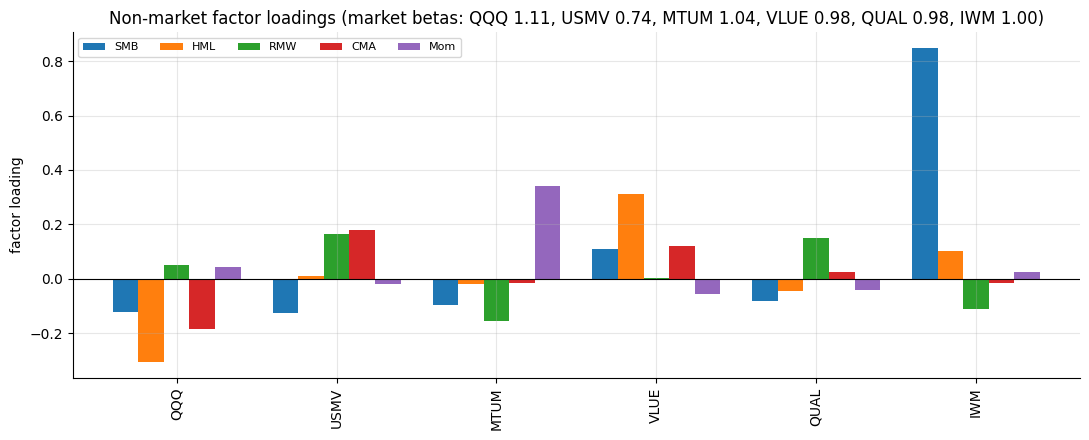

In [3]:
betas = pd.DataFrame({t: fits[t].betas for t in ETFS})
ax = betas.drop(index="Mkt-RF").T.plot.bar(figsize=(11, 4.5), width=0.8)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("factor loading")
ax.set_title("Non-market factor loadings (market betas: "
             + ", ".join(f"{t} {fits[t].betas['Mkt-RF']:.2f}" for t in ETFS) + ")")
ax.legend(fontsize=8, ncol=5)
plt.tight_layout()

**Do the ETFs load where their names promise?** Yes, cleanly — this is the validation half of the exercise:

- **MTUM** loads on momentum at $\beta_{\text{Mom}} \approx 0.34$ with $t \approx 49$ — not a subtle effect.
- **VLUE** loads on value at $\beta_{\text{HML}} \approx 0.31$ ($t \approx 29$), plus a small-cap tilt consistent with where value stocks live.
- **QUAL** loads on profitability, $\beta_{\text{RMW}} \approx 0.15$ ($t \approx 18$) — smaller, because "quality" indices blend profitability with other screens.
- **IWM** is almost a pure size trade: $\beta_{\text{SMB}} \approx 0.85$ ($t \approx 145$) and $R^2 = 0.98$ — the Russell 2000 *is* market + size, full stop.
- **USMV** has market beta $\approx 0.74$ — it delivers the low-vol promise structurally — with defensive RMW/CMA tilts and a slight anti-momentum lean.
- **QQQ** is levered market ($\beta \approx 1.11$) with strongly negative HML ($\approx -0.31$): an anti-value, mega-cap growth vehicle, exactly as advertised.

**And the alphas?** Five of six are statistically indistinguishable from zero — |t| < 1.4, point estimates between −1.2% and +0.5% a year. *That is the punchline, not a disappointment.* These funds charge 15–35bp to deliver factor exposure, and factor exposure is what they deliver; after controlling for it, nothing is left. The one apparent exception, QQQ at $\hat\alpha \approx +3.3\%$/yr with $t \approx 2.3$, deserves suspicion rather than celebration: it is one marginally significant result among six tests (multiple comparisons), it coincides with a specific historical episode (the 2015–2025 mega-cap run), and "Nasdaq-100 membership" is plausibly a proxy for factors outside this six-factor menu (profitability measured differently, intangibles, an AI-era industry bet). A $t$ of 2.3 over eleven years is what luck routinely looks like in finance.

## 2. Exposures are not constants: rolling betas

The full-sample regression averages over regimes. Estimating the same model in rolling 252-day windows shows how QQQ's identity has drifted.

beta ranges across windows:
     Mkt-RF   Mom   HML
min    1.02 -0.14 -0.50
max    1.25  0.26 -0.05


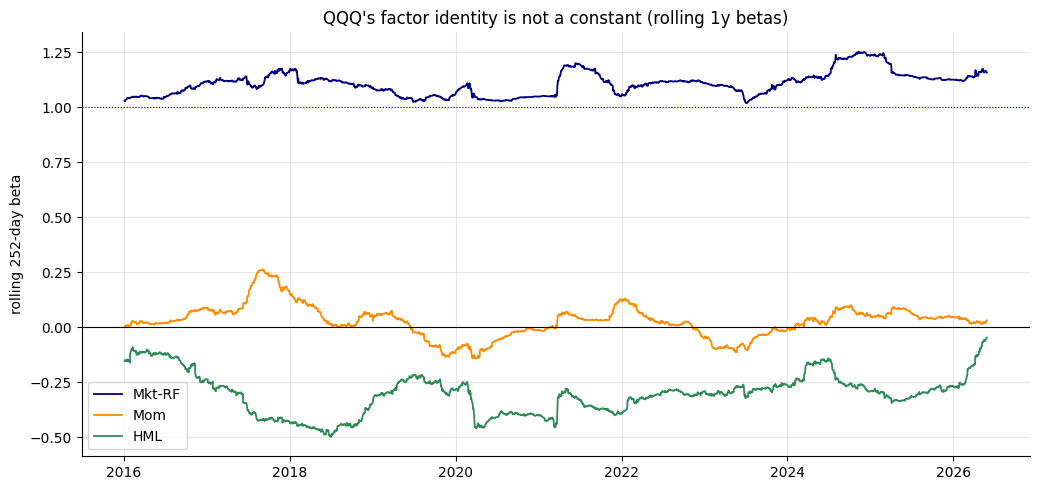

In [4]:
rb = rolling_betas(rets["QQQ"] - rf, F, window=252)

fig, ax = plt.subplots(figsize=(10.5, 5))
for col, color in [("Mkt-RF", "navy"), ("Mom", "darkorange"), ("HML", "seagreen")]:
    ax.plot(rb[col], lw=1.3, color=color, label=col)
ax.axhline(0, color="k", lw=0.8)
ax.axhline(1, color="navy", lw=0.8, ls=":")
ax.set_ylabel("rolling 252-day beta")
ax.set_title("QQQ's factor identity is not a constant (rolling 1y betas)")
ax.legend()
plt.tight_layout()

print("beta ranges across windows:")
print(rb[["Mkt-RF", "Mom", "HML"]].agg(["min", "max"]).round(2))

**Interpretation.** The market beta is comparatively stable (roughly 1.0–1.2), but the **momentum loading swings sign** — QQQ behaves like a momentum asset when tech has been winning (its holdings *become* the momentum portfolio, as in 2020–21 and the AI rally) and like an anti-momentum asset after reversals, when the momentum factor rotates into whatever replaced tech. The HML loading is persistently negative but far from constant. Two research consequences: (i) a full-sample beta is a *time average* that may describe no actual year; (ii) any risk model or hedging program keyed to static loadings silently accumulates basis risk as the loadings wander. This is the same lesson as notebook 03's, one level up: parameters we call constants are state variables we have declined to model.

## 3. How distinct are the factors themselves?

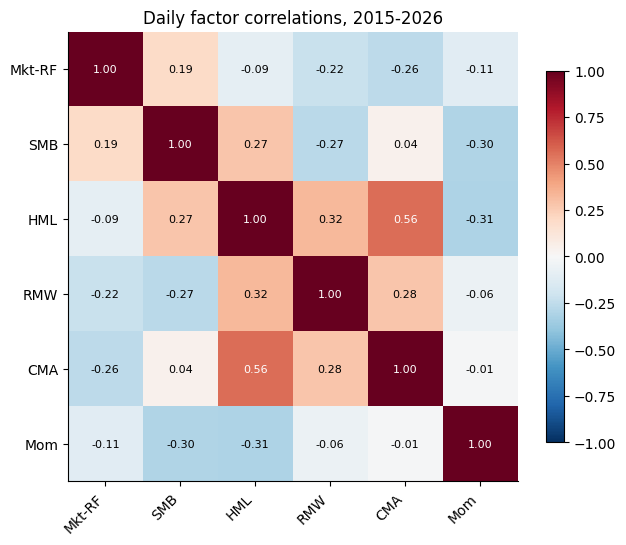

In [5]:
C = F.corr()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(C, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(FACTORS)), FACTORS, rotation=45, ha="right")
ax.set_yticks(range(len(FACTORS)), FACTORS)
for i in range(len(FACTORS)):
    for j in range(len(FACTORS)):
        ax.text(j, i, f"{C.iloc[i, j]:.2f}", ha="center", va="center",
                fontsize=8, color="white" if abs(C.iloc[i, j]) > 0.5 else "black")
fig.colorbar(im, shrink=0.8)
ax.set_title("Daily factor correlations, 2015-2026")
ax.grid(False)
plt.tight_layout()

**Interpretation.** The factors are correlated but not redundant. The notable structure: **HML and CMA at +0.56** — value firms tend to be conservative-investment firms, and Fama & French themselves note CMA subsumes much of HML in the five-factor model — and **momentum's negative correlations with value and size** (−0.31, −0.30), which is why value-plus-momentum blends diversify so well and why the momentum crash of a value rebound is a recurring event. Multicollinearity at these levels inflates the standard errors of individual betas somewhat but does not threaten identification.

## Limitations

- **OLS $t$-statistics assume i.i.d. errors**, which notebook 03 shows daily returns are not (volatility clustering). Newey–West or heteroskedasticity-robust errors would shrink the reported $t$'s modestly; the huge loadings survive, the borderline QQQ alpha becomes even more borderline.
- **The factor menu is a choice.** Alphas are only defined *relative to* a model; adding a Nasdaq/tech factor would likely absorb QQQ's alpha entirely. "Alpha" is always a statement about the regressors you omitted.
- **Factor returns are portfolios, not tradables.** The Ken French factors are long–short paper portfolios ignoring shorting costs, fees, and implementation lag; investable factor returns are systematically smaller (Frazzini, Israel & Moskowitz, 2018 estimate meaningful but survivable implementation costs).
- **Eleven years is one regime sample.** This window contains a historically unusual growth-over-value run; loadings are well identified, but *premia* (the factor means) are not — the standard error of a factor's mean return over 11 years is several percent annualized.
- ETF returns are total returns from adjusted closes; factor data end a month earlier than prices, so the last few weeks are excluded by the alignment.

The sober summary: factor regressions are excellent at telling you **what you own**, mediocre at telling you **what it will pay**. Models clarify uncertainty; they do not eliminate it.

---

**References.** Fama & French (1993, 2015) · Carhart (1997) · Jegadeesh & Titman (1993) · Frazzini, Israel & Moskowitz (2018) · Harvey, Liu & Zhu (2016), "...and the Cross-Section of Expected Returns" — on why $t = 2.3$ should not excite anyone.